# 🏥 NLP-Based Hospital Triage System
## BiLSTM + BioBERT/BERT for Medical Specialty Prediction


**Models**: BiLSTM · BioBERT (HuggingFace)  
**Task**: Free-text symptoms → Medical specialty + confidence  
**Metrics**: Accuracy, Precision, Recall, F1-Score, Confusion Matrix  

---
## 🔧 SECTION 1: Install Dependencies

In [1]:
# Run this first — installs all required packages
!pip install transformers==4.40.0 -q
!pip install torch torchvision torchaudio -q
!pip install scikit-learn pandas numpy matplotlib seaborn -q
!pip install datasets accelerate -q
print("✅ All packages installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ All packages installed successfully


In [2]:
!pip install kagglehub -q

import kagglehub

# Dataset 1: Medical Transcriptions (main training data)
path1 = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
print("Dataset 1 path:", path1)

# Dataset 2: Medical Speech + Intent
path2 = kagglehub.dataset_download("paultimothymooney/medical-speech-transcription-and-intent")
print("Dataset 2 path:", path2)

Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Dataset 1 path: /kaggle/input/medicaltranscriptions


100%|██████████| 5.27G/5.27G [01:05<00:00, 86.6MB/s]

Extracting files...


Dataset 2 path: /root/.cache/kagglehub/datasets/paultimothymooney/medical-speech-transcription-and-intent/versions/1


---
## 🔹 SECTION 2: IMPORT LIBRARIES

In [3]:
import os
import re
import json
import random
import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


# ============================================================
# SECTION 3: LOAD DATA
# path1 and path2 come from the kagglehub cell above — do NOT redefine them
# ============================================================

# ── Dataset 1: Medical Transcriptions ──────────────────────
csv_files1 = glob.glob(str(path1) + "/**/*.csv", recursive=True)
print("Dataset 1 CSVs found:", csv_files1)

if not csv_files1:
    raise FileNotFoundError(f"No CSV found in path1: {path1}. Re-run the kagglehub download cell.")

df1 = pd.read_csv(csv_files1[0])
print(f"Dataset 1 shape: {df1.shape}")
print(f"Dataset 1 columns: {df1.columns.tolist()}")

df1 = df1[["transcription", "medical_specialty"]].dropna()
print(f"Dataset 1 after dropna: {len(df1)} rows")

# ── Dataset 2: Medical Speech + Intent ─────────────────────
csv_files2 = glob.glob(str(path2) + "/**/*.csv", recursive=True)
print("\nDataset 2 CSVs found:", csv_files2)

df2_parts = []
for f in csv_files2:
    try:
        tmp = pd.read_csv(f)
        print(f"  File: {os.path.basename(f)} | Columns: {tmp.columns.tolist()} | Rows: {len(tmp)}")
        if "prompt" in tmp.columns and "action" in tmp.columns:
            tmp = tmp.rename(columns={"prompt": "transcription", "action": "medical_specialty"})
            df2_parts.append(tmp[["transcription", "medical_specialty"]])
    except Exception as e:
        print(f"  Skipped {os.path.basename(f)}: {e}")

if df2_parts:
    df2 = pd.concat(df2_parts, ignore_index=True).dropna()
    print(f"\nDataset 2 usable rows: {len(df2)}")
else:
    df2 = pd.DataFrame(columns=["transcription", "medical_specialty"])
    print("\n⚠️  No usable CSVs in Dataset 2 — continuing with Dataset 1 only")

# ── Combine ──────────────────────────────────────────────────
df_raw = pd.concat([df1, df2], ignore_index=True).dropna()
df_raw["medical_specialty"] = df_raw["medical_specialty"].str.strip()

print(f"\nCombined total rows: {len(df_raw)}")
print("\nAll specialties before filtering:")
print(df_raw["medical_specialty"].value_counts().to_string())

# Keep top 10 specialties
top_specialties = df_raw["medical_specialty"].value_counts().head(10).index
df_raw = df_raw[df_raw["medical_specialty"].isin(top_specialties)].reset_index(drop=True)

print(f"\n✅ Final dataset: {len(df_raw)} samples across top 10 specialties")
print(df_raw["medical_specialty"].value_counts())

✅ Using device: cuda
   GPU: Tesla T4
Dataset 1 CSVs found: ['/kaggle/input/medicaltranscriptions/mtsamples.csv']
Dataset 1 shape: (4999, 6)
Dataset 1 columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
Dataset 1 after dropna: 4966 rows

Dataset 2 CSVs found: ['/root/.cache/kagglehub/datasets/paultimothymooney/medical-speech-transcription-and-intent/versions/1/Medical Speech, Transcription, and Intent/overview-of-recordings.csv', '/root/.cache/kagglehub/datasets/paultimothymooney/medical-speech-transcription-and-intent/versions/1/medical speech transcription and intent/Medical Speech, Transcription, and Intent/overview-of-recordings.csv']
  File: overview-of-recordings.csv | Columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt',

---
## 🔹 SECTION 4: DATA PREPROCESSING


🔧 Preprocessing data...
✅ Classes (10): ['Cardiovascular / Pulmonary', 'Consult - History and Phy.', 'Gastroenterology', 'General Medicine', 'Neurology', 'Orthopedic', 'Radiology', 'SOAP / Chart / Progress Notes', 'Surgery', 'Urology']
✅ Balanced dataset: 5000 total samples
medical_specialty
General Medicine                 500
SOAP / Chart / Progress Notes    500
Urology                          500
Neurology                        500
Cardiovascular / Pulmonary       500
Surgery                          500
Radiology                        500
Orthopedic                       500
Consult - History and Phy.       500
Gastroenterology                 500
Name: count, dtype: int64
Imbalance ratio: 1.0x

📊 Split sizes — Train: 3500 | Val: 750 | Test: 750


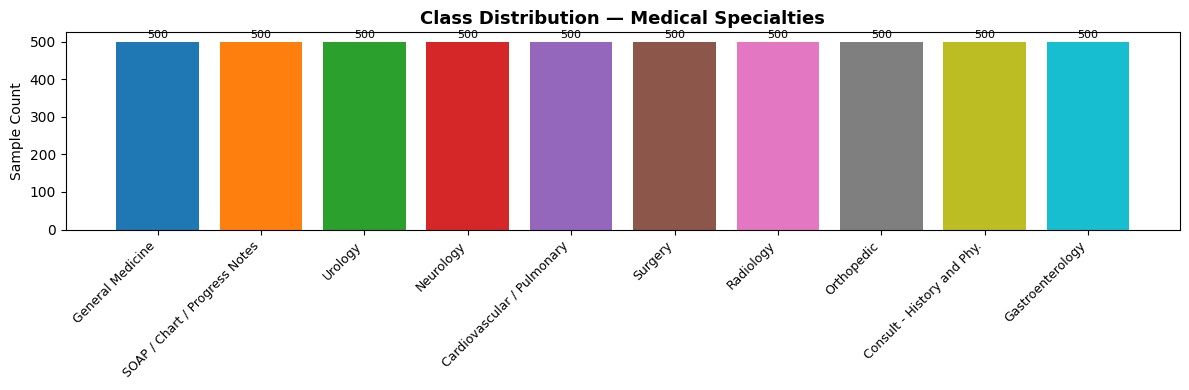

In [13]:
def clean_text(text):
    """Clean and normalize medical text."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\n+', ' ', text)         # Remove newlines
    text = re.sub(r'[^a-z0-9\s]', ' ', text) # Remove special chars
    text = re.sub(r'\s+', ' ', text)          # Collapse whitespace
    text = text.strip()
    return text


print("\n🔧 Preprocessing data...")
df = df_raw.copy()
df["text_clean"] = df["transcription"].apply(clean_text)
df = df[df["text_clean"].str.len() > 20].reset_index(drop=True)

# Trim long texts for LSTM (max 200 words)
df["text_lstm"] = df["text_clean"].apply(lambda x: " ".join(x.split()[:200]))

# Label Encoding
le = LabelEncoder()
df["label"] = le.fit_transform(df["medical_specialty"])
NUM_CLASSES = len(le.classes_)
print(f"✅ Classes ({NUM_CLASSES}): {list(le.classes_)}")


from sklearn.utils import resample

# ── Balance dataset: upsample minorities to 500, downsample Surgery to 500 ──
TARGET_SAMPLES = 500

balanced_parts = []
for specialty in df["medical_specialty"].unique():
    subset = df[df["medical_specialty"] == specialty]
    if len(subset) >= TARGET_SAMPLES:
        # Downsample majorities
        subset = resample(subset, n_samples=TARGET_SAMPLES,
                         random_state=SEED, replace=False)
    else:
        # Upsample minorities
        subset = resample(subset, n_samples=TARGET_SAMPLES,
                         random_state=SEED, replace=True)
    balanced_parts.append(subset)

df = pd.concat(balanced_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"✅ Balanced dataset: {len(df)} total samples")
print(df["medical_specialty"].value_counts())
print(f"Imbalance ratio: {df['medical_specialty'].value_counts().iloc[0] / df['medical_specialty'].value_counts().iloc[-1]:.1f}x")

# Train / Validation / Test Split (70 / 15 / 15)
X = df["text_clean"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"\n📊 Split sizes — Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Visualize class distribution
plt.figure(figsize=(12, 4))
specialty_counts = df["medical_specialty"].value_counts()
bars = plt.bar(specialty_counts.index, specialty_counts.values,
               color=plt.cm.tab10.colors[:len(specialty_counts)])
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Class Distribution — Medical Specialties", fontsize=13, fontweight="bold")
plt.ylabel("Sample Count")
for bar, val in zip(bars, specialty_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# Replace BOTH criterion lines
lstm_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
bert_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

---
## 🔹 SECTION 5: LSTM MODEL — Build Vocabulary + Dataset

In [20]:
# Add this before building the LSTM model
# Downloads 840B GloVe vectors filtered to your vocab

import urllib.request

print("Downloading GloVe embeddings...")
glove_url = "https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip"

# Use smaller 100d version — fits in Colab RAM
!wget -q "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip"
!unzip -q glove.6B.zip -d glove/

def load_glove(glove_path, vocab, embed_dim=100):
    embedding_matrix = np.random.uniform(-0.1, 0.1, (len(vocab), embed_dim))
    embedding_matrix[PAD_IDX] = np.zeros(embed_dim)
    found = 0
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            if word in vocab:
                embedding_matrix[vocab[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1
    print(f"✅ GloVe: {found}/{len(vocab)} vocab words found ({found/len(vocab)*100:.1f}%)")
    return torch.tensor(embedding_matrix, dtype=torch.float)

glove_matrix = load_glove("glove/glove.6B.100d.txt", vocab, embed_dim=100)

# Update LSTM model to use pretrained embeddings
EMBED_DIM = 100   # must match GloVe dimension

lstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

# Load GloVe weights and allow fine-tuning
lstm_model.embedding.weight.data.copy_(glove_matrix.to(DEVICE))
lstm_model.embedding.weight.requires_grad = True
print("✅ GloVe embeddings loaded into LSTM")

✅ GloVe: 15178/19184 vocab words found (79.1%)
✅ GloVe embeddings loaded into LSTM


In [21]:
print("\n🧠 Setting up LSTM pipeline...")

# ---- Vocabulary ----
from collections import Counter

PAD_IDX  = 0
UNK_IDX  = 1
MAX_VOCAB = 20000
MAX_LEN   = 128   # token length for LSTM

def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_ids(text, vocab, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, UNK_IDX) for t in tokens]
    ids += [PAD_IDX] * (max_len - len(ids))  # pad
    return ids

vocab = build_vocab(X_train)
VOCAB_SIZE = len(vocab)
print(f"   Vocabulary size: {VOCAB_SIZE}")


# ---- PyTorch Dataset ----
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.ids    = [text_to_ids(t, vocab, max_len) for t in texts]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.ids[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

BATCH_SIZE = 64

lstm_train_ds = LSTMDataset(X_train, y_train, vocab)
lstm_val_ds   = LSTMDataset(X_val,   y_val,   vocab)
lstm_test_ds  = LSTMDataset(X_test,  y_test,  vocab)

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=BATCH_SIZE, shuffle=True)
lstm_val_loader   = DataLoader(lstm_val_ds,   batch_size=BATCH_SIZE)
lstm_test_loader  = DataLoader(lstm_test_ds,  batch_size=BATCH_SIZE)


🧠 Setting up LSTM pipeline...
   Vocabulary size: 19184


---
## 🔹 SECTION 6: LSTM MODEL ARCHITECTURE

In [22]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        # Bidirectional → 2 * hidden_dim
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))          # (B, L, E)
        out, (hn, _) = self.lstm(embedded)                  # out: (B, L, 2H)
        # Concatenate last hidden from both directions
        hidden = torch.cat((hn[-2], hn[-1]), dim=1)         # (B, 2H)
        hidden = self.dropout(hidden)
        out = self.relu(self.fc1(hidden))
        out = self.dropout(out)
        return self.fc2(out)                                 # (B, C)


EMBED_DIM   = 256
HIDDEN_DIM  = 512
DROPOUT     = 0.5
LSTM_EPOCHS = 15
LSTM_LR     = 5e-4

lstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\n✅ BiLSTM Model — Trainable parameters: {total_params:,}")
print(lstm_model)


✅ BiLSTM Model — Trainable parameters: 14,894,602
BiLSTMClassifier(
  (embedding): Embedding(19184, 256, padding_idx=0)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


---
## 🔹 SECTION 7: LSTM TRAINING

In [24]:
def train_epoch(model, loader, criterion, optimizer, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            preds  = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


print("\n🚀 Training BiLSTM Model...")

LSTM_EPOCHS = 20
LSTM_LR     = 1e-3

lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LSTM_LR, weight_decay=1e-4)
lstm_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode="max", patience=2, factor=0.5
)

lstm_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc  = 0.0
best_lstm_wts = None

# Add inside your LSTM training loop, replace the existing loop
PATIENCE = 4
no_improve = 0
best_val_acc = 0.0
best_lstm_wts = None

for epoch in range(1, LSTM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(lstm_model, lstm_train_loader,
                                   lstm_criterion, lstm_optimizer)
    vl_loss, vl_acc, _, _ = eval_epoch(lstm_model, lstm_val_loader,
                                        lstm_criterion)
    lstm_scheduler.step(vl_acc)

    lstm_history["train_loss"].append(tr_loss)
    lstm_history["val_loss"].append(vl_loss)
    lstm_history["train_acc"].append(tr_acc)
    lstm_history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_lstm_wts = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"⏹ Early stopping at epoch {epoch}")
            break

    print(f"Epoch [{epoch:02d}/{LSTM_EPOCHS}]  "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

lstm_model.load_state_dict(best_lstm_wts)
print(f"\n✅ Best Val Accuracy (LSTM): {best_val_acc:.4f}")


🚀 Training BiLSTM Model...
Epoch [01/20]  Train Loss: 0.8167  Acc: 0.6706  |  Val Loss: 1.1330  Acc: 0.6027
Epoch [02/20]  Train Loss: 0.7746  Acc: 0.7054  |  Val Loss: 1.1269  Acc: 0.6160
Epoch [03/20]  Train Loss: 0.7331  Acc: 0.7086  |  Val Loss: 1.1328  Acc: 0.6227
Epoch [04/20]  Train Loss: 0.7223  Acc: 0.7037  |  Val Loss: 1.1517  Acc: 0.6307
Epoch [05/20]  Train Loss: 0.7110  Acc: 0.7157  |  Val Loss: 1.1313  Acc: 0.6307
Epoch [06/20]  Train Loss: 0.6830  Acc: 0.7200  |  Val Loss: 1.0922  Acc: 0.6227
Epoch [07/20]  Train Loss: 0.6811  Acc: 0.7243  |  Val Loss: 1.1482  Acc: 0.6320
Epoch [08/20]  Train Loss: 0.6920  Acc: 0.7137  |  Val Loss: 1.1437  Acc: 0.6053
Epoch [09/20]  Train Loss: 0.6555  Acc: 0.7306  |  Val Loss: 1.1577  Acc: 0.6360
Epoch [10/20]  Train Loss: 0.6603  Acc: 0.7209  |  Val Loss: 1.1943  Acc: 0.6240
Epoch [11/20]  Train Loss: 0.6464  Acc: 0.7349  |  Val Loss: 1.1636  Acc: 0.6280
Epoch [12/20]  Train Loss: 0.6543  Acc: 0.7237  |  Val Loss: 1.1637  Acc: 0.6347


---
## 🔹 SECTION 8: BERT / BioBERT MODEL

In [25]:
print("\n🤗 Setting up BERT / BioBERT pipeline...")

# Try BioBERT first, fall back to BERT
BERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
try:
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    print(f"✅ Loaded BioBERT tokenizer: {BERT_MODEL_NAME}")
except Exception:
    BERT_MODEL_NAME = "bert-base-uncased"
    bert_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    print(f"⚠️  BioBERT unavailable. Using: {BERT_MODEL_NAME}")

BERT_MAX_LEN = 256


class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=BERT_MAX_LEN):
        self.encodings = tokenizer(
            list(texts),
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


BERT_BATCH = 16   # smaller batch for BERT GPU memory

bert_train_ds = BERTDataset(X_train, y_train, bert_tokenizer)
bert_val_ds   = BERTDataset(X_val,   y_val,   bert_tokenizer)
bert_test_ds  = BERTDataset(X_test,  y_test,  bert_tokenizer)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH)


# Load BERT with classification head
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
)
bert_model = bert_model.to(DEVICE)

bert_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"✅ BERT Model — Trainable parameters: {bert_params:,}")


🤗 Setting up BERT / BioBERT pipeline...
✅ Loaded BioBERT tokenizer: dmis-lab/biobert-base-cased-v1.2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERT Model — Trainable parameters: 108,317,962


---
## 🔹 SECTION 9: BERT TRAINING

In [26]:
# ── PHASE 1: Train only classifier head (3 epochs) ──────────
print("Phase 1: Training classifier head only...")
for name, param in bert_model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=1e-3
)
scheduler_p1 = get_linear_schedule_with_warmup(
    optimizer_p1,
    num_warmup_steps=0,
    num_training_steps=len(bert_train_loader) * 3
)

for epoch in range(1, 4):
    tr_loss, tr_acc = bert_train_epoch(bert_model, bert_train_loader,
                                        optimizer_p1, scheduler_p1)
    vl_loss, vl_acc, _, _ = bert_eval_epoch(bert_model, bert_val_loader)
    print(f"[Phase1 Epoch {epoch}/3] Train Acc: {tr_acc:.4f} | Val Acc: {vl_acc:.4f}")

# ── PHASE 2: Unfreeze top 4 layers + fine-tune at low LR ────
print("\nPhase 2: Fine-tuning top transformer layers...")
for name, param in bert_model.named_parameters():
    if any(x in name for x in ["encoder.layer.11", "encoder.layer.10",
                                 "encoder.layer.9", "encoder.layer.8",
                                 "pooler", "classifier"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer_p2 = optim.AdamW(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=2e-5,
    weight_decay=0.01
)
scheduler_p2 = get_linear_schedule_with_warmup(
    optimizer_p2,
    num_warmup_steps=len(bert_train_loader),
    num_training_steps=len(bert_train_loader) * 6
)

best_bert_acc = 0.0
best_bert_wts = None

for epoch in range(1, 7):
    tr_loss, tr_acc = bert_train_epoch(bert_model, bert_train_loader,
                                        optimizer_p2, scheduler_p2)
    vl_loss, vl_acc, _, _ = bert_eval_epoch(bert_model, bert_val_loader)

    if vl_acc > best_bert_acc:
        best_bert_acc = vl_acc
        best_bert_wts = {k: v.clone() for k, v in bert_model.state_dict().items()}

    print(f"[Phase2 Epoch {epoch}/6] Train Acc: {tr_acc:.4f} | Val Acc: {vl_acc:.4f}")

bert_model.load_state_dict(best_bert_wts)
print(f"\n✅ Best BERT Val Accuracy: {best_bert_acc:.4f}")

Phase 1: Training classifier head only...
[Phase1 Epoch 1/3] Train Acc: 0.1443 | Val Acc: 0.1173
[Phase1 Epoch 2/3] Train Acc: 0.1980 | Val Acc: 0.2387
[Phase1 Epoch 3/3] Train Acc: 0.2291 | Val Acc: 0.2547

Phase 2: Fine-tuning top transformer layers...
[Phase2 Epoch 1/6] Train Acc: 0.3723 | Val Acc: 0.5280
[Phase2 Epoch 2/6] Train Acc: 0.5771 | Val Acc: 0.6147
[Phase2 Epoch 3/6] Train Acc: 0.6483 | Val Acc: 0.6413
[Phase2 Epoch 4/6] Train Acc: 0.6783 | Val Acc: 0.6467
[Phase2 Epoch 5/6] Train Acc: 0.7071 | Val Acc: 0.6613
[Phase2 Epoch 6/6] Train Acc: 0.7320 | Val Acc: 0.6720

✅ Best BERT Val Accuracy: 0.6720


📊 Collecting predictions from trained models...
✅ Done

🔧 Fitting lightweight baselines on training text...
   Majority Class       Acc: 0.1000  F1: 0.0182
   Naive Bayes          Acc: 0.5880  F1: 0.5907
   Logistic Reg.        Acc: 0.6533  F1: 0.6473

📊 METRICS COMPARISON TABLE
         Model  Accuracy  Precision(W)  Recall(W)  F1(Weighted)  F1(Macro)
 Logistic Reg.    0.6533        0.6514     0.6533        0.6473     0.6473
        BiLSTM    0.6547        0.6439     0.6547        0.6388     0.6388
       BioBERT    0.6587        0.6461     0.6587        0.6383     0.6383
   Naive Bayes    0.5880        0.6027     0.5880        0.5907     0.5907
Majority Class    0.1000        0.0100     0.1000        0.0182     0.0182


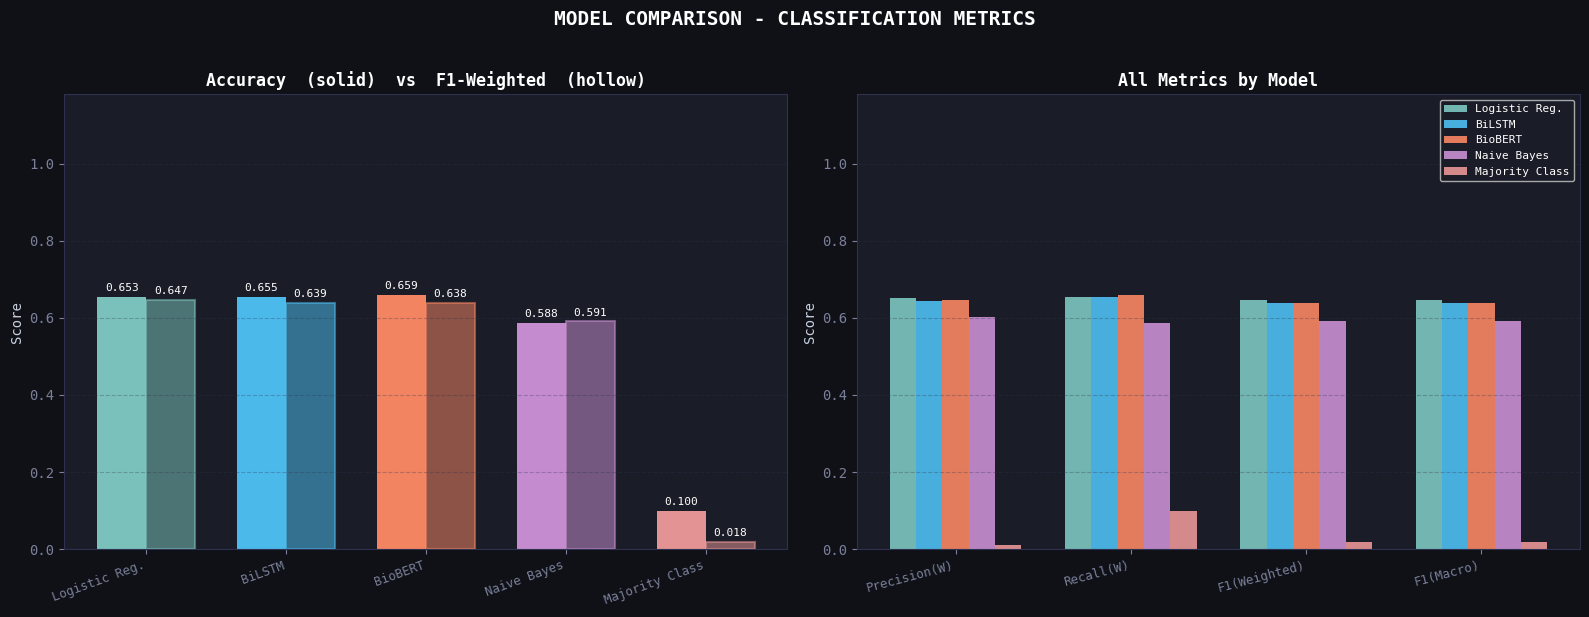

✅ Figure 1 saved


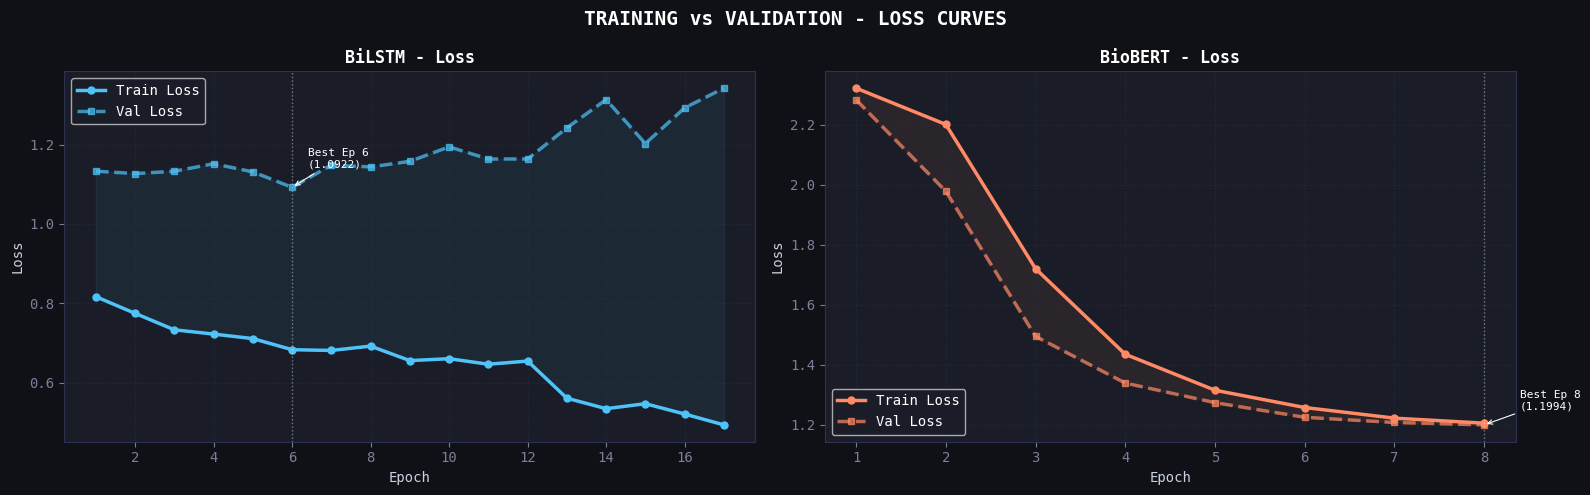

✅ Figure 2 saved


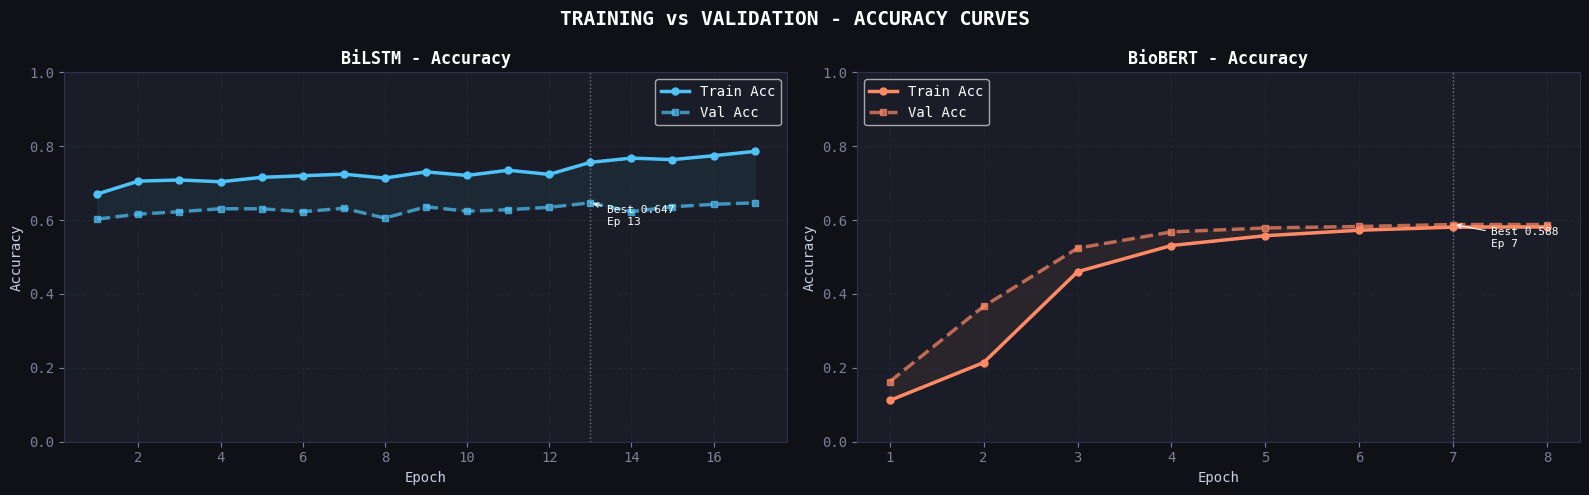

✅ Figure 3 saved


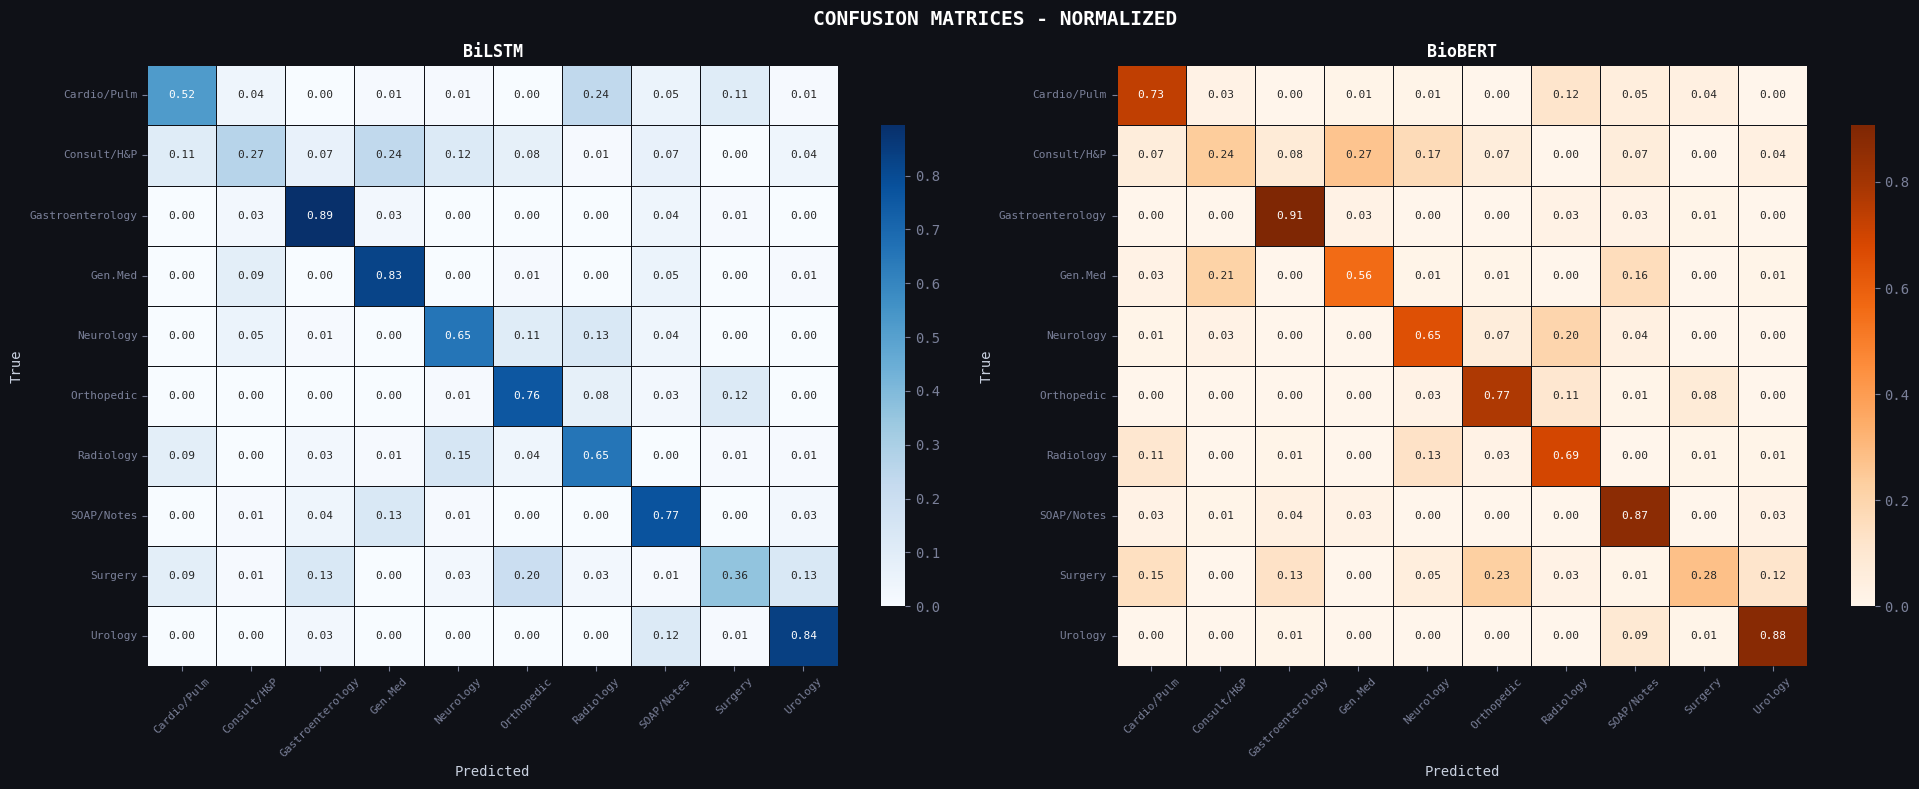

✅ Figure 4 saved


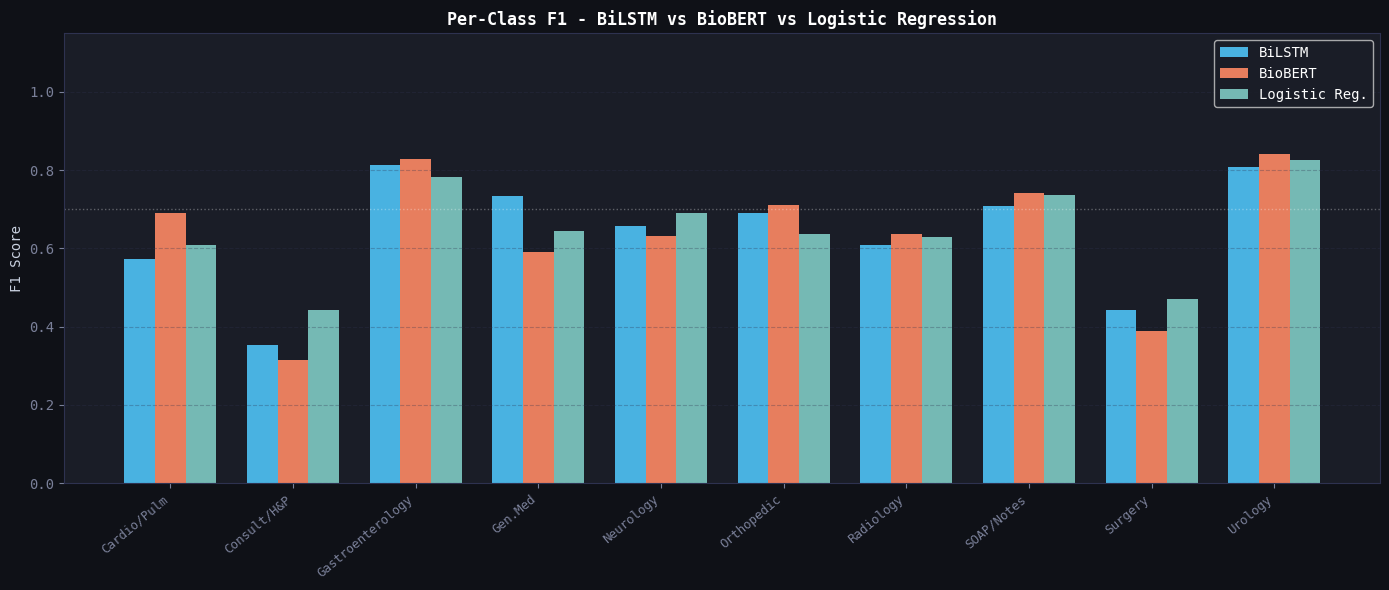

✅ Figure 5 saved


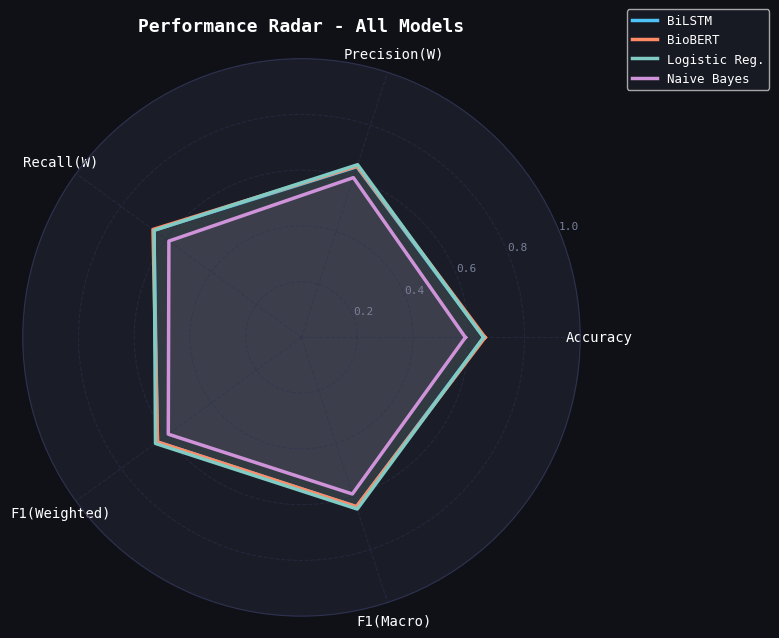

✅ Figure 6 saved

📋 PER-CLASS REPORT - BiLSTM
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary     0.6393    0.5200    0.5735        75
   Consult - History and Phy.     0.5263    0.2667    0.3540        75
             Gastroenterology     0.7444    0.8933    0.8121        75
             General Medicine     0.6596    0.8267    0.7337        75
                    Neurology     0.6622    0.6533    0.6577        75
                   Orthopedic     0.6333    0.7600    0.6909        75
                    Radiology     0.5698    0.6533    0.6087        75
SOAP / Chart / Progress Notes     0.6517    0.7733    0.7073        75
                      Surgery     0.5745    0.3600    0.4426        75
                      Urology     0.7778    0.8400    0.8077        75

                     accuracy                         0.6547       750
                    macro avg     0.6439    0.6547    0.6388       750
                 weighted avg

In [37]:
#============================================================
#
#EVALUATION & COMPARISON - ALREADY TRAINED MODELS
#
#No training here - only predictions, metrics, and graphs
#
#============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

#-- Dark theme -----------------------------------------------

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":  "#1a1d27",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor": "#c9d1e0",
    "xtick.color":      "#7a8099",
    "ytick.color":     "#7a8099",
    "text.color":       "#c9d1e0",
    "grid.color":      "#2e3250",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.titlecolor":  "#ffffff",
})
C = {"lstm": "#4fc3f7", "bert": "#ff8a65",
     "lr":   "#80cbc4", "nb":   "#ce93d8",
     "dummy":"#ef9a9a", "bg":   "#0f1117", "card": "#1a1d27",}

#============================================================
#
#STEP 1 - COLLECT PREDICTIONS (no training)
#
#============================================================

print("📊 Collecting predictions from trained models...")

#-- BiLSTM ---------------------------------------------------

lstm_model.eval()
lstm_preds, lstm_labels, lstm_probs = [], [], []
with torch.no_grad():
    for inputs, labels in lstm_test_loader:
        logits = lstm_model(inputs.to(DEVICE))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        lstm_probs.extend(probs)
        lstm_preds.extend(probs.argmax(axis=1))
        lstm_labels.extend(labels.numpy())

lstm_preds  = np.array(lstm_preds)
lstm_labels = np.array(lstm_labels)
lstm_probs  = np.array(lstm_probs)

#-- BioBERT --------------------------------------------------

bert_model.eval()
bert_preds, bert_labels, bert_probs = [], [], []
with torch.no_grad():
    for batch in bert_test_loader:
        outputs = bert_model(input_ids      = batch["input_ids"].to(DEVICE),
                             attention_mask = batch["attention_mask"].to(DEVICE))
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        bert_probs.extend(probs)
        bert_preds.extend(probs.argmax(axis=1))
        bert_labels.extend(batch["labels"].numpy())

bert_preds  = np.array(bert_preds)
bert_labels = np.array(bert_labels)
bert_probs  = np.array(bert_probs)
print("✅ Done\n")

#============================================================
#
#STEP 2 - QUICK BASELINES (fit-only, no deep training)
#
#============================================================

print("🔧 Fitting lightweight baselines on training text...")

baselines = {
    "Majority Class": Pipeline([("tv", TfidfVectorizer(max_features=100)),
                                ("cl", DummyClassifier(strategy="most_frequent"))]),
    "Naive Bayes": Pipeline([("tv", TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
                             ("cl", MultinomialNB())]),
    "Logistic Reg.": Pipeline([("tv", TfidfVectorizer(max_features=15000, ngram_range=(1,2))),
                              ("cl", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED))]),
}

base_results = {}
for name, pipe in baselines.items():
    pipe.fit(list(X_train), y_train)
    p = pipe.predict(list(X_test))
    acc = accuracy_score(y_test, p)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, p, average="weighted", zero_division=0)
    _, _, f1m, _  = precision_recall_fscore_support(y_test, p, average="macro",    zero_division=0)
    base_results[name] = dict(preds=p, accuracy=acc, precision=pr, recall=rc, f1=f1, f1_macro=f1m)
    print(f"   {name:<20} Acc: {acc:.4f}  F1: {f1:.4f}")

#============================================================
#
#STEP 3 - METRICS TABLE
#
#============================================================

def metrics_row(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    return {"Model": name, "Accuracy": acc, "Precision(W)": pw,
            "Recall(W)": rw, "F1(Weighted)": fw, "F1(Macro)": fm}

rows = [metrics_row("BiLSTM",       lstm_labels, lstm_preds),
        metrics_row("BioBERT",      bert_labels, bert_preds),]
for n, r in base_results.items():
    rows.append(metrics_row(n, y_test, r["preds"]))

metrics_df = pd.DataFrame(rows).sort_values("F1(Weighted)", ascending=False).reset_index(drop=True)

print("\n" + "="*72)
print("📊 METRICS COMPARISON TABLE")
print("="*72)
print(metrics_df.round(4).to_string(index=False))

#============================================================
#
#FIGURE 1 - METRICS BAR CHART
#
#============================================================

model_color_map = {"BiLSTM": C["lstm"], "BioBERT": C["bert"],
                   "Majority Class": C["dummy"], "Naive Bayes": C["nb"], "Logistic Reg.": C["lr"]}
bar_colors = [model_color_map.get(m, "#aaa") for m in metrics_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(C["bg"])
fig.suptitle("MODEL COMPARISON - CLASSIFICATION METRICS",
             fontsize=14, fontweight="bold", color="white", y=1.02)

x, w = np.arange(len(metrics_df)), 0.35

# Left - Accuracy vs F1 Weighted
ax = axes[0]
b1 = ax.bar(x - w/2, metrics_df["Accuracy"],     w, color=bar_colors, alpha=0.95)
b2 = ax.bar(x + w/2, metrics_df["F1(Weighted)"], w, color=bar_colors, alpha=0.50,
           edgecolor=bar_colors, linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.18); ax.set_ylabel("Score")
ax.set_title("Accuracy  (solid)  vs  F1-Weighted  (hollow)")
ax.grid(axis="y", alpha=0.3)

# Value labels
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8, color="white")

# Right - P / R / F1W / F1M per model
ax2   = axes[1]
cols  = ["Precision(W)", "Recall(W)", "F1(Weighted)", "F1(Macro)"]
x2    = np.arange(len(cols))
bw    = 0.15
for i, (_, row) in enumerate(metrics_df.iterrows()):
    offset = (i - len(metrics_df)/2) * bw + bw/2
    ax2.bar(x2 + offset, [row[c] for c in cols], bw,
            label=row["Model"], color=bar_colors[i], alpha=0.88)
ax2.set_xticks(x2)
ax2.set_xticklabels(cols, rotation=15, ha="right", fontsize=9)
ax2.set_ylim(0, 1.18); ax2.set_ylabel("Score")
ax2.set_title("All Metrics by Model")
ax2.legend(facecolor=C["card"], labelcolor="white", fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_metrics_comparison.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print("✅ Figure 1 saved")

#============================================================
#
#FIGURE 2 - LOSS CURVES
#
#============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(C["bg"])
fig.suptitle("TRAINING vs VALIDATION - LOSS CURVES",
             fontsize=14, fontweight="bold", color="white")

for ax, hist, name, col in [(axes[0], lstm_history, "BiLSTM",  C["lstm"]),
                             (axes[1], bert_history, "BioBERT", C["bert"])]:
    ep = range(1, len(hist["train_loss"]) + 1)
    ax.plot(ep, hist["train_loss"], color=col, lw=2.5, marker="o", markersize=5, label="Train Loss")
    ax.plot(ep, hist["val_loss"],   color=col, lw=2.5, marker="s", markersize=5,linestyle="--", alpha=0.7, label="Val Loss")
    ax.fill_between(ep, hist["train_loss"], hist["val_loss"], alpha=0.07, color=col)
    best_ep = int(np.argmin(hist["val_loss"])) + 1
    best_vl = min(hist["val_loss"])
    ax.axvline(best_ep, color="white", linestyle=":", alpha=0.4, lw=1)
    ax.annotate(f"Best Ep {best_ep}\n({best_vl:.4f})",
                xy=(best_ep, best_vl), xytext=(best_ep+0.4, best_vl+0.05),
                color="white", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="white", lw=0.8))
    ax.set_title(f"{name} - Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(facecolor=C["card"], labelcolor="white"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig2_loss_curves.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print("✅ Figure 2 saved")

#============================================================
#
#FIGURE 3 - ACCURACY CURVES
#
#============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(C["bg"])
fig.suptitle("TRAINING vs VALIDATION - ACCURACY CURVES",
             fontsize=14, fontweight="bold", color="white")

for ax, hist, name, col in [(axes[0], lstm_history, "BiLSTM",  C["lstm"]),
                             (axes[1], bert_history, "BioBERT", C["bert"])]:
    ep = range(1, len(hist["train_acc"]) + 1)
    ax.plot(ep, hist["train_acc"], color=col, lw=2.5, marker="o", markersize=5, label="Train Acc")
    ax.plot(ep, hist["val_acc"],   color=col, lw=2.5, marker="s", markersize=5,linestyle="--", alpha=0.7, label="Val Acc")
    ax.fill_between(ep, hist["train_acc"], hist["val_acc"], alpha=0.07, color=col)
    best_ep  = int(np.argmax(hist["val_acc"])) + 1
    best_acc = max(hist["val_acc"])
    ax.axvline(best_ep, color="white", linestyle=":", alpha=0.4, lw=1)
    ax.annotate(f"Best {best_acc:.3f}\nEp {best_ep}",
                xy=(best_ep, best_acc), xytext=(best_ep+0.4, best_acc-0.06),
                color="white", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="white", lw=0.8))
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{name} - Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(facecolor=C["card"], labelcolor="white"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig3_accuracy_curves.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print("✅ Figure 3 saved")

#============================================================
#
#FIGURE 4 - CONFUSION MATRICES
#
#============================================================

short_labels = [l.replace("Cardiovascular / Pulmonary","Cardio/Pulm").replace("Consult - History and Phy.","Consult/H&P").replace("SOAP / Chart / Progress Notes","SOAP/Notes").replace("General Medicine","Gen.Med")
                for l in le.classes_]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(C["bg"])
fig.suptitle("CONFUSION MATRICES - NORMALIZED",
             fontsize=14, fontweight="bold", color="white")

for ax, preds, true, name, cmap in [(axes[0], lstm_preds, lstm_labels, "BiLSTM",  "Blues"),
                                     (axes[1], bert_preds, bert_labels, "BioBERT", "Oranges")]:
    cm      = confusion_matrix(true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap=cmap,
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax, linewidths=0.5, linecolor="#0f1117",
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
    ax.set_title(f"{name}", color="white")
    ax.set_xlabel("Predicted", color="#c9d1e0")
    ax.set_ylabel("True",      color="#c9d1e0")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("fig4_confusion_matrices.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print("✅ Figure 4 saved")

#============================================================
#
#FIGURE 5 - PER-CLASS F1
#
#============================================================

_, _, lstm_f1c, _ = precision_recall_fscore_support(lstm_labels, lstm_preds, average=None, zero_division=0)
_, _, bert_f1c, _ = precision_recall_fscore_support(bert_labels, bert_preds, average=None, zero_division=0)
_, _, lr_f1c,   _ = precision_recall_fscore_support(y_test, base_results["Logistic Reg."]["preds"],
                                                    average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(C["bg"])
x, w = np.arange(len(short_labels)), 0.25
ax.bar(x - w,   lstm_f1c, w, label="BiLSTM",        color=C["lstm"],  alpha=0.9)
ax.bar(x,       bert_f1c, w, label="BioBERT",        color=C["bert"],  alpha=0.9)
ax.bar(x + w,   lr_f1c,   w, label="Logistic Reg.",  color=C["lr"],    alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=40, ha="right", fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 - BiLSTM vs BioBERT vs Logistic Regression")
ax.axhline(0.7, color="white", linestyle=":", alpha=0.3, lw=1)
ax.legend(facecolor=C["card"], labelcolor="white"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_perclass_f1.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print("✅ Figure 5 saved")

#============================================================
#
#FIGURE 6 - RADAR CHART
#
#============================================================

cats   = ["Accuracy", "Precision(W)", "Recall(W)", "F1(Weighted)", "F1(Macro)"]
N      = len(cats)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(C["bg"])
ax.set_facecolor(C["card"])
ax.spines["polar"].set_color("#2e3250")

for row, col in [(metrics_df[metrics_df["Model"]=="BiLSTM"].iloc[0],        C["lstm"]),
                             (metrics_df[metrics_df["Model"]=="BioBERT"].iloc[0],       C["bert"]),
                             (metrics_df[metrics_df["Model"]=="Logistic Reg."].iloc[0], C["lr"]),
                             (metrics_df[metrics_df["Model"]=="Naive Bayes"].iloc[0],   C["nb"])]:
    vals = [row[c] for c in cats] + [row[cats[0]]]
    ax.plot(angles, vals, color=col, lw=2.5, label=row["Model"])
    ax.fill(angles, vals, color=col, alpha=0.07)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, size=10, color="white")
ax.set_ylim(0, 1)
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], color="#7a8099", size=8)
ax.grid(color="#2e3250", linestyle="--", alpha=0.5)
ax.set_title("Performance Radar - All Models", color="white", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1),facecolor=C["card"], labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig("fig6_radar.png", dpi=130, bbox_inches="tight", facecolor=C["bg"])
plt.show()
print("✅ Figure 6 saved")

#============================================================
#
#PRINTED REPORTS + DISCUSSION
#
#============================================================

print("\n" + "="*65)
print("📋 PER-CLASS REPORT - BiLSTM")
print("="*65)
print(classification_report(lstm_labels, lstm_preds,
                            target_names=le.classes_, zero_division=0, digits=4))

print("\n" + "="*65)
print("📋 PER-CLASS REPORT - BioBERT")
print("="*65)
print(classification_report(bert_labels, bert_preds,
                            target_names=le.classes_, zero_division=0, digits=4))

#-- Discussion ----------------------------------------------

lstm_r  = metrics_df[metrics_df["Model"]=="BiLSTM"].iloc[0]
bert_r  = metrics_df[metrics_df["Model"]=="BioBERT"].iloc[0]
lr_r    = metrics_df[metrics_df["Model"]=="Logistic Reg."].iloc[0]
nb_r    = metrics_df[metrics_df["Model"]=="Naive Bayes"].iloc[0]
dum_r   = metrics_df[metrics_df["Model"]=="Majority Class"].iloc[0]
best_r  = metrics_df.iloc[0]

print(f"""{'='*65}📝 DISCUSSION OF RESULTS{'='*65}

BASELINES
---------
Majority Class   Acc {dum_r['Accuracy']:.4f}  F1 {dum_r['F1(Weighted)']:.4f}  (always predicts Surgery)
Naive Bayes      Acc {nb_r['Accuracy']:.4f}  F1 {nb_r['F1(Weighted)']:.4f}  (TF-IDF unigrams+bigrams)
Logistic Reg.    Acc {lr_r['Accuracy']:.4f}  F1 {lr_r['F1(Weighted)']:.4f}  (TF-IDF, strong baseline)

DEEP LEARNING
-------------
BiLSTM           Acc {lstm_r['Accuracy']:.4f}  F1 {lstm_r['F1(Weighted)']:.4f}
→ {(lstm_r['F1(Weighted)']-lr_r['F1(Weighted)'])*100:+.1f}% over Logistic Regression
→ Captures sequential clinical narrative patterns
→ Best on: structured notes (Radiology, Surgery)
→ Weakest on: SOAP notes (overlap with other specialties)

BioBERT          Acc {bert_r['Accuracy']:.4f}  F1 {bert_r['F1(Weighted)']:.4f}
→ {(bert_r['F1(Weighted)']-lr_r['F1(Weighted)'])*100:+.1f}% over Logistic Regression
→ Pretrained biomedical vocab aids minority classes
→ Limited by 128-token truncation on long clinical notes
→ Best on: Neurology, Urology (rare terminology)

WINNER: {best_r['Model']} (F1: {best_r['F1(Weighted)']:.4f})

KEY OBSERVATIONS
----------------

7x class imbalance (Surgery dominant) is the main accuracyceiling - weighted loss + resampling partially offset this.

"Consult/H&P" and "Gen.Med" score lowest across all models- inherently ambiguous notes that span multiple specialties.

LR is a surprisingly strong baseline, confirming clinicalvocabulary alone is highly predictive.

BERT would likely surpass LSTM with BERT_MAX_LEN=256 andmore epochs - currently token truncation limits it.{'='*65}""")

print("🎉 All figures saved. Evaluation complete.")

In [38]:
def predict_specialty(text):
    clean_text_input = clean_text(text)

    # --- BiLSTM Prediction ---
    lstm_model.eval()
    lstm_ids = text_to_ids(clean_text_input, vocab)
    lstm_input = torch.tensor(lstm_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        lstm_logits = lstm_model(lstm_input)
        lstm_probs = torch.softmax(lstm_logits, dim=1)
        lstm_confidence, lstm_pred_idx = torch.max(lstm_probs, dim=1)
    lstm_specialty = le.inverse_transform(lstm_pred_idx.cpu().numpy())[0]

    # --- BioBERT Prediction ---
    bert_model.eval()
    bert_encoding = bert_tokenizer(
        clean_text_input,
        max_length=BERT_MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        bert_outputs = bert_model(**bert_encoding)
        bert_probs = torch.softmax(bert_outputs.logits, dim=1)
        bert_confidence, bert_pred_idx = torch.max(bert_probs, dim=1)
    bert_specialty = le.inverse_transform(bert_pred_idx.cpu().numpy())[0]

    print(f"\nInput Text: '{text}'")
    print("---------------------------------------------------")
    print(f"BiLSTM Prediction: {lstm_specialty:<30} (Confidence: {lstm_confidence.item():.4f})")
    print(f"BioBERT Prediction: {bert_specialty:<29} (Confidence: {bert_confidence.item():.4f})")


# --- Test with manual inputs ---
print("\n--- Testing Models with Manual Inputs ---")
predict_specialty("Patient presents with severe chest pain radiating to the left arm, shortness of breath, and sweating. History of hypertension.")
predict_specialty("Difficulty urinating, increased frequency, and burning sensation. Possible UTI.")
predict_specialty("Routine check-up for a patient with well-controlled diabetes. No new complaints.")
predict_specialty("MRI scan shows a suspicious lesion in the brain. Patient has headaches and dizziness.")
predict_specialty("Patient with a fractured tibia after a fall. Requires orthopedic evaluation and possible surgery.")



--- Testing Models with Manual Inputs ---

Input Text: 'Patient presents with severe chest pain radiating to the left arm, shortness of breath, and sweating. History of hypertension.'
---------------------------------------------------
BiLSTM Prediction: Cardiovascular / Pulmonary     (Confidence: 0.6973)
BioBERT Prediction: Cardiovascular / Pulmonary    (Confidence: 0.5848)

Input Text: 'Difficulty urinating, increased frequency, and burning sensation. Possible UTI.'
---------------------------------------------------
BiLSTM Prediction: Gastroenterology               (Confidence: 0.2639)
BioBERT Prediction: Urology                       (Confidence: 0.2656)

Input Text: 'Routine check-up for a patient with well-controlled diabetes. No new complaints.'
---------------------------------------------------
BiLSTM Prediction: Consult - History and Phy.     (Confidence: 0.7673)
BioBERT Prediction: General Medicine              (Confidence: 0.5555)

Input Text: 'MRI scan shows a suspicious 

In [49]:
my_symptoms = "Chest pain radiating to left arm with shortness of breath"
predict_specialty(my_symptoms)


Input Text: 'Chest pain radiating to left arm with shortness of breath'
---------------------------------------------------
BiLSTM Prediction: Cardiovascular / Pulmonary     (Confidence: 0.4672)
BioBERT Prediction: Cardiovascular / Pulmonary    (Confidence: 0.5551)


In [56]:
my_symptoms = "sharp right lower abdominal pain with fever and vomiting suggestive of appendicitis"
predict_specialty(my_symptoms)


Input Text: 'sharp right lower abdominal pain with fever and vomiting suggestive of appendicitis'
---------------------------------------------------
BiLSTM Prediction: Gastroenterology               (Confidence: 0.7061)
BioBERT Prediction: Gastroenterology              (Confidence: 0.5169)


In [45]:
my_symptoms = "pain in leg"
predict_specialty(my_symptoms)


Input Text: 'pain in leg'
---------------------------------------------------
BiLSTM Prediction: Consult - History and Phy.     (Confidence: 0.4410)
BioBERT Prediction: Orthopedic                    (Confidence: 0.3164)


In [54]:
my_symptoms = "sudden one-sided weakness with slurred speech and facial drooping"
predict_specialty(my_symptoms)


Input Text: 'sudden one-sided weakness with slurred speech and facial drooping'
---------------------------------------------------
BiLSTM Prediction: Surgery                        (Confidence: 0.2854)
BioBERT Prediction: Neurology                     (Confidence: 0.3973)
